## Questão 1 – Definição do problema analítico

**Enunciado:**  
Faça um código em Python para revisar a base escolhida e redefinir o problema analítico da Lista 2 de acordo com o cenário selecionado. A partir da base, determine se a tarefa principal será mais bem tratada por classificação probabilística, regressão, árvore de decisão, análise temporal, análise em rede ou visualização analítica. Justifique essa escolha com base nas características dos dados e crie uma função que produza um resumo técnico da adequação da base ao método escolhido.

### Raciocínio

Na Lista 1, confirmamos que a base **Telco-Customer-Churn** tem 7.043 clientes, alvo binário (`Churn`), e que `TotalCharges` precisou ser convertida para numérico (11 registros com valor vazio tratados por imputação). A escolha do método na Lista 2 segue diretamente dessas características estruturais já verificadas.

A estratégia é criar uma função `analytical_problem_summary` que examina a base de forma objetiva (por meio de tipos de atributos, distribuição do alvo, variáveis disponíveis para cada método, etc.), e devolve uma tabela de adequação para cada família de modelos coberta na Lista 2.

Dessa forma, a escolha do método principal passa a ser guiada pelas características reais da base, e não apenas por preferência ou conveniência.

### Desenvolvimento

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
# Carregamento e pré-processamento mínimo herdado da Lista 1
df_raw = pd.read_csv('../../data/Telco-Customer-Churn.csv')

df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Valores ausentes restantes: {df.isna().sum().sum()}')
df.head(3)

Dimensões: 7043 linhas × 21 colunas
Valores ausentes restantes: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [4]:
def analytical_problem_summary(df: pd.DataFrame, target: str) -> dict:
    """
    Produz um resumo técnico da adequação da base ao conjunto de métodos da Lista 2.
    Retorna um dicionário com:
      - 'target_profile'  : características do alvo
      - 'feature_profile' : contagem e proporção de atributos por tipo
      - 'method_fit'      : DataFrame com avaliação de adequação por método
    """

    result = {}

    # ── 1. Perfil do alvo ────────────────────────────────────────────────────
    target_series = df[target]
    is_binary     = target_series.nunique() == 2
    class_counts  = target_series.value_counts()
    minority_pct  = round(class_counts.min() / len(target_series) * 100, 2)
    majority_pct  = round(class_counts.max() / len(target_series) * 100, 2)
    imbalance_ratio = round(class_counts.max() / class_counts.min(), 2)

    result['target_profile'] = {
        'coluna'          : target,
        'tipo'            : str(target_series.dtype),
        'classes'         : sorted(target_series.unique().tolist()),
        'binaria'         : is_binary,
        'classe_majoritaria_pct': majority_pct,
        'classe_minoritaria_pct': minority_pct,
        'razao_desbalanceamento': imbalance_ratio
    }

    # ── 2. Perfil dos atributos ──────────────────────────────────────────────
    features = df.drop(columns=[target])

    num_cols  = features.select_dtypes(include='number').columns.tolist()
    cat_cols  = features.select_dtypes(include='object').columns.tolist()
    bool_cols = features.select_dtypes(include='bool').columns.tolist()

    # Detecta colunas binárias (apenas 2 valores únicos, mesmo sendo object)
    binary_cat = [c for c in cat_cols if features[c].nunique() == 2]

    # Verifica se há alguma coluna com perfil temporal (não é o caso aqui, mas registra)
    date_cols = features.select_dtypes(include='datetime').columns.tolist()
    has_temporal_proxy = 'tenure' in features.columns  # tenure é proxy temporal

    result['feature_profile'] = {
        'total_atributos'  : len(features.columns),
        'numericas'        : len(num_cols),
        'categoricas'      : len(cat_cols),
        'booleanas'        : len(bool_cols),
        'datas_reais'      : len(date_cols),
        'proxy_temporal'   : has_temporal_proxy,
        'binarias_cat'     : len(binary_cat),
        'cols_numericas'   : num_cols,
        'cols_categoricas' : cat_cols,
        'cols_binarias_cat': binary_cat
    }

    # ── 3. Adequação por método ──────────────────────────────────────────────
    #
    # Escala: 'Alta' / 'Média' / 'Baixa'
    # Critérios: tipo do alvo, existência de variáveis numéricas, variáveis
    # categóricas binárias, presença de proxy temporal, tamanho da base.

    n_num  = len(num_cols)
    n_cat  = len(cat_cols)
    n_rows = len(df)

    method_rows = [
        {
            'Método'           : 'Classificação probabilística (Naive Bayes)',
            'Adequação'        : 'Alta' if is_binary and (n_cat + n_num) > 5 else 'Média',
            'Justificativa'    : (
                f'Alvo binário ({target}), base com {n_cat} atributos categóricos '
                f'e {n_num} numéricos — perfil compatível com GaussianNB e BernoulliNB. '
                f'Desbalanceamento de {imbalance_ratio}× é gerenciável.'
            ),
            'Limitação'        : 'Assume independência condicional entre atributos, o que pode não valer.'
        },
        {
            'Método'           : 'Classificação linear (Regressão Logística)',
            'Adequação'        : 'Alta' if is_binary and n_rows > 100 else 'Média',
            'Justificativa'    : (
                f'Alvo binário, {n_rows} registros — tamanho suficiente para estabilidade. '
                'Produz probabilidades calibradas, úteis para ordenar clientes por risco.'
            ),
            'Limitação'        : 'Relações não lineares entre variáveis podem ser subestimadas.'
        },
        {
            'Método'           : 'Regressão (alvo numérico derivado)',
            'Adequação'        : 'Média',
            'Justificativa'    : (
                f'Não há alvo numérico natural, mas MonthlyCharges ou TotalCharges '
                'podem ser usados como variável-resposta em um subproblema coerente.'
            ),
            'Limitação'        : 'Requer redefinição do problema; o alvo original (Churn) não é numérico.'
        },
        {
            'Método'           : 'Árvore de Decisão',
            'Adequação'        : 'Alta' if n_rows > 500 else 'Média',
            'Justificativa'    : (
                f'{n_cat} atributos categóricos + {n_num} numéricos beneficiam particionamento hierárquico. '
                f'Modelo interpretável. {n_rows} registros {"permitem" if n_rows > 500 else "limitam"} controle de profundidade.'
            ),
            'Limitação'        : 'Propensa a overfitting sem controle de profundidade; instável com pequenas variações.'
        },
        {
            'Método'           : 'Análise Temporal (Séries Temporais)',
            'Adequação'        : 'Baixa' if not has_temporal_proxy else 'Média',
            'Justificativa'    : (
                f'{"Não há coluna de data real." if not has_temporal_proxy else "Proxy temporal (tenure) disponível."} '
                'Série pode ser construída por coorte, mas padrões temporais são limitados.'
            ),
            'Limitação'        : 'Série gerada por agregação de coorte, não por evolução real no tempo — conclusões têm alcance limitado.'
        },
        {
            'Método'           : 'Análise de Redes',
            'Adequação'        : 'Baixa',
            'Justificativa'    : (
                'Base tabular de clientes individuais; não há relações explícitas entre eles. '
                'Rede pode ser construída por similaridade de perfil, mas o grafo é artificial.'
            ),
            'Limitação'        : 'Aplicação metodologicamente fraca — rede não representa relacionamentos reais entre clientes.'
        },
        {
            'Método'           : 'Visualização Analítica',
            'Adequação'        : 'Alta' if n_rows > 1000 and len(features.columns) > 10 else 'Média',
            'Justificativa'    : (
                f'{n_rows} registros, {len(features.columns)} atributos, alvo binário bem definido — '
                f'perfil {"ideal" if n_rows > 1000 and len(features.columns) > 10 else "apropriado"} para análise exploratória.'
            ),
            'Limitação'        : 'Suporta comunicação dos resultados, não produz predições por si só.'
        },
    ]

    result['method_fit'] = pd.DataFrame(method_rows)

    return result


q1 = analytical_problem_summary(df, target='Churn')

print('=== Perfil do alvo ===')
for k, v in q1['target_profile'].items():
    print(f'  {k}: {v}')

print('\n=== Perfil dos atributos ===')
for k, v in q1['feature_profile'].items():
    if not isinstance(v, list):
        print(f'  {k}: {v}')

print('\n=== Adequação por método ===')
display(
    q1['method_fit'][['Método', 'Adequação', 'Justificativa', 'Limitação']]
)

=== Perfil do alvo ===
  coluna: Churn
  tipo: str
  classes: ['No', 'Yes']
  binaria: True
  classe_majoritaria_pct: 73.46
  classe_minoritaria_pct: 26.54
  razao_desbalanceamento: 2.77

=== Perfil dos atributos ===
  total_atributos: 20
  numericas: 4
  categoricas: 16
  booleanas: 0
  datas_reais: 0
  proxy_temporal: True
  binarias_cat: 5

=== Adequação por método ===


,Método,Adequação,Justificativa,Limitação
0,Classificação probabilística (Naive Bayes),Alta,"Alvo binário (Churn), base com 16 atributos ca...",Assume independência condicional entre atribut...
1,Classificação linear (Regressão Logística),Alta,"Alvo binário, 7043 registros — tamanho suficie...",Relações não lineares entre variáveis podem se...
2,Regressão (alvo numérico derivado),Média,"Não há alvo numérico natural, mas MonthlyCharg...",Requer redefinição do problema; o alvo origina...
3,Árvore de Decisão,Alta,16 atributos categóricos + 4 numéricos benefic...,Propensa a overfitting sem controle de profund...
4,Análise Temporal (Séries Temporais),Média,Proxy temporal (tenure) disponível. Série pode...,"Série gerada por agregação de coorte, não por ..."
5,Análise de Redes,Baixa,Base tabular de clientes individuais; não há r...,Aplicação metodologicamente fraca — rede não r...
6,Visualização Analítica,Alta,"7043 registros, 20 atributos, alvo binário bem...","Suporta comunicação dos resultados, não produz..."


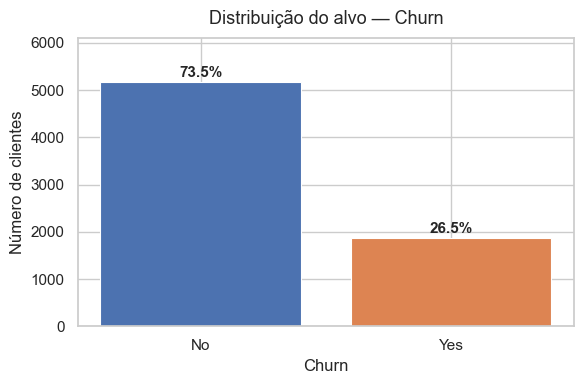

Classe 'No' (permanece): 5,174 clientes (73.5%)
Classe 'Yes' (churn):    1,869 clientes (26.5%)
Razão de desbalanceamento: 2.77×


In [5]:
# ── Gráfico 1: distribuição do alvo (Churn) ──────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    churn_counts.index, churn_counts.values,
    color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.8
)
for bar, pct in zip(bars, churn_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_title('Distribuição do alvo — Churn', fontsize=13, pad=10)
ax.set_xlabel('Churn')
ax.set_ylabel('Número de clientes')
ax.set_ylim(0, churn_counts.max() * 1.18)
plt.tight_layout()
plt.show()

print(f"Classe 'No' (permanece): {churn_counts['No']:,} clientes ({churn_pct['No']:.1f}%)")
print(f"Classe 'Yes' (churn):    {churn_counts['Yes']:,} clientes ({churn_pct['Yes']:.1f}%)")
print(f"Razão de desbalanceamento: {q1['target_profile']['razao_desbalanceamento']}×")

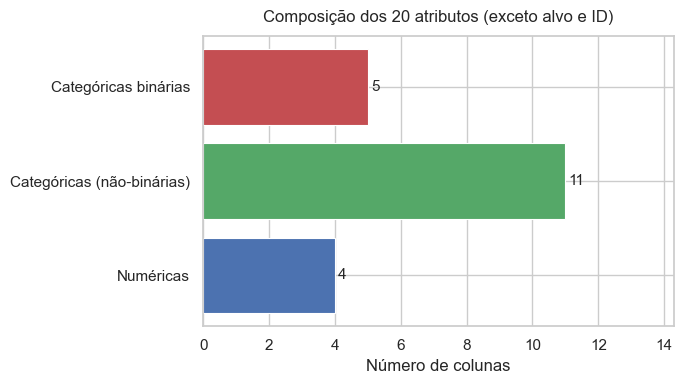

In [6]:
# ── Gráfico 2: composição da base por tipo de atributo ───────────────────────
fp = q1['feature_profile']
tipo_labels = ['Numéricas', 'Categóricas (não-binárias)', 'Categóricas binárias']
tipo_counts = [
    fp['numericas'],
    fp['categoricas'] - fp['binarias_cat'],
    fp['binarias_cat']
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(tipo_labels, tipo_counts, color=['#4C72B0', '#55A868', '#C44E52'],
               edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, tipo_counts):
    ax.text(
        bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
        str(count), va='center', fontsize=11
    )
ax.set_title(f'Composição dos {fp["total_atributos"]} atributos (exceto alvo e ID)',
             fontsize=12, pad=10)
ax.set_xlabel('Número de colunas')
ax.set_xlim(0, max(tipo_counts) * 1.3)
plt.tight_layout()
plt.show()

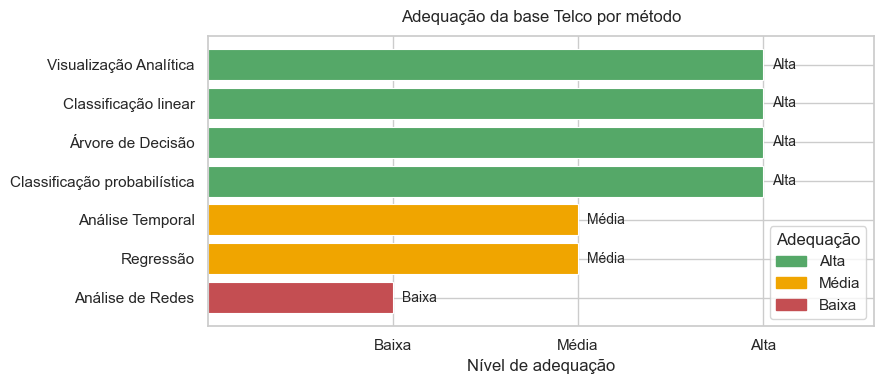

In [7]:
# ── Gráfico 3: mapa de adequação dos métodos ─────────────────────────────────
fit_map   = {'Alta': 3, 'Média': 2, 'Baixa': 1}
color_map = {'Alta': '#55A868', 'Média': '#F0A500', 'Baixa': '#C44E52'}

method_fit = q1['method_fit'].copy()
method_fit['score']  = method_fit['Adequação'].map(fit_map)
method_fit['cor']    = method_fit['Adequação'].map(color_map)
method_fit = method_fit.sort_values('score')

labels_short = [
    m.split('(')[0].strip() for m in method_fit['Método']
]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    labels_short, method_fit['score'],
    color=method_fit['cor'].tolist(), edgecolor='white', linewidth=0.8
)
for bar, adq in zip(bars, method_fit['Adequação']):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        adq, va='center', fontsize=10
    )

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Baixa', 'Média', 'Alta'])
ax.set_xlim(0, 3.6)
ax.set_title('Adequação da base Telco por método', fontsize=12, pad=10)
ax.set_xlabel('Nível de adequação')

patches = [
    mpatches.Patch(color='#55A868', label='Alta'),
    mpatches.Patch(color='#F0A500', label='Média'),
    mpatches.Patch(color='#C44E52', label='Baixa'),
]
ax.legend(handles=patches, loc='lower right', title='Adequação')
plt.tight_layout()
plt.show()

### Conclusão da Questão 1

A análise da base mostrou que o problema principal continua sendo o cenário clássico de classificação supervisionada binária observado na Lista 1, onde o objetivo é prever se um cliente irá cancelar o serviço (`Churn`) ou não. A base possui uma quantidade suficiente de registros e atributos para permitir experimentos consistentes com diferentes técnicas de aprendizado de máquina, além de apresentar uma combinação interessante de variáveis categóricas e numéricas.

O desbalanceamento moderado entre as classes indica que apenas utilizar acurácia como métrica pode levar a interpretações enganosas, já que o modelo pode atingir bons resultados simplesmente favorecendo a classe majoritária. Por isso, métricas como recall, precisão e F1-score serão mais importantes nas próximas etapas, principalmente porque, do ponto de vista do negócio, deixar de identificar um cliente com alta chance de cancelamento pode gerar impactos maiores do que realizar uma intervenção desnecessária.

Além disso, a estrutura dos atributos torna métodos como Naive Bayes, Regressão Logística e Árvore de Decisão bastante adequados para o problema. Em especial, a Árvore de Decisão tende a oferecer uma vantagem interpretativa relevante, já que suas regras de separação podem ser facilmente traduzidas em ações práticas para retenção de clientes.

Por fim, conclui-se que a base continua sendo apropriada para estudos de classificação e análise preditiva, permitindo comparar diferentes abordagens de modelagem e avaliar não apenas desempenho estatístico, mas também utilidade prática no contexto de tomada de decisão no meio empresarial.